In [27]:
import pandas as pd 
import os 
import json
import numpy as np

In [28]:
path_to_data = "../../../data/conv-trs/ecir-2026/human-eval/survey_parsed.csv"

In [29]:
df = pd.read_csv(path_to_data)

In [30]:
df['annotator'].unique()

array(['Wolfgang', 'Yas', 'Ewald', 'Tejas Srinivasan', 'Comet [AI]',
       'Dana Marti', nan], dtype=object)

In [31]:
comet = df[df['annotator'] == "Comet [AI]"]

In [32]:
# compute mean and variance for each metric 
cols = ['relevance', 'diversity', 'sustainability', 'popularity']

for col in cols: 
    print(f"{round(comet[col].mean(), 2)} ({round(comet[col].var(), 2)})")


-0.2 (0.82)
-0.29 (0.69)
-0.5 (0.61)
-0.32 (0.68)


In [33]:
df['annotator'].value_counts()

annotator
Wolfgang            101
Ewald               101
Comet [AI]          101
Dana Marti          101
Yas                  41
Tejas Srinivasan     18
Name: count, dtype: int64

In [34]:
df.head()

,query_id,query,annotator,relevance,popularity,diversity,sustainability,feedback
0,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,Wolfgang,1.0,-1.0,-1.0,0.0,NaN
1,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,Yas,-1.0,0.0,0.0,-3.0,NaN
2,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,Ewald,-1.0,-1.0,-1.0,-1.0,NaN
3,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,Tejas Srinivasan,-1.0,-1.0,-1.0,-1.0,NaN
4,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,Comet [AI],-1.0,1.0,-2.0,-1.0,QUERY 88 EVALUATION:\n\nQ1 - Better Match (Sco...


In [35]:
df[df['annotator'] == 'Dana Marti'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 5 to 462
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   query_id        101 non-null    object 
 1   query           101 non-null    object 
 2   annotator       101 non-null    object 
 3   relevance       101 non-null    float64
 4   popularity      101 non-null    float64
 5   diversity       101 non-null    float64
 6   sustainability  101 non-null    float64
 7   feedback        1 non-null      object 
dtypes: float64(4), object(4)
memory usage: 7.1+ KB


In [36]:
df[df['relevance'].isna()]["query_id"]

6            c_p_0_pop_high_hard
36     c_p_0_pop_low_sustainable
463                          NaN
464                          NaN
465                          NaN
466                          NaN
467                          NaN
468                          NaN
469                          NaN
Name: query_id, dtype: object

In [37]:
df_human = df[df['annotator'] != 'Comet [AI]']

In [38]:
count_4 = 0
for i in df_human['query_id'].value_counts():
    if i>=4: 
        count_4+=1
print(count_4)

52


In [39]:
filtered_df = df_human[df_human.groupby('query_id')['query_id'].transform('count') >= 3]

In [40]:
len(filtered_df['query_id'].unique())

101

In [41]:
cols = ['relevance', 'diversity', 'sustainability', 'popularity']

for col in cols: 
    print(f"{round(filtered_df[col].mean(), 2)} ({round(filtered_df[col].var(), 2)})")

-0.16 (1.44)
-0.16 (0.7)
-0.52 (1.32)
-0.22 (0.88)


## Majority Vote

In [42]:
qids = filtered_df['query_id'].unique().tolist()

In [43]:
def get_majority_vote(results):
    VOTE_MAP = {
        -2.0: "L2",
        -1.0: "L2",
        0.0: "Neither",
        1.0: "L1", 
        2.0: "L1",
        -3.0: "Neither",
        np.nan: "Neither", 
        None: "Neither", 
    }

    mapped = [VOTE_MAP.get(i, "Neither") for i in results]
    maj_vote = max(set(mapped), key=mapped.count)

    return maj_vote

In [186]:
only3 = df_human[df_human['annotator'].isin(['Wolfgang', 'Ewald', 'Dana Marti'])]

In [157]:
def get_unanimous_vote(results):
    VOTE_MAP = {
        -2.0: "L2",
        -1.0: "L2",
        0.0: "Neither",
        1.0: "L1", 
        2.0: "L1",
        -3.0: "Neither",
        np.nan: "Neither", 
        None: "Neither", 
    }

    # Map raw annotations to standardized labels
    mapped = [VOTE_MAP.get(i, "Neither") for i in results]

    # Check if all annotators agree
    if len(set(mapped)) == 1:
        return mapped[0]
    else:
        return "Neither"

In [187]:
un_votes = []
for qid in qids: 
    qid_df = only3[only3['query_id'] == qid]
    query = qid_df['query'].values[0]

    result = {
        'query_id': qid, 
        'query': query
    }
    for col in cols: 
        res = qid_df[col].values
        
        vote = get_unanimous_vote(res)
        result[col] = vote

    un_votes.append(result)

In [188]:
un_votes_df = pd.DataFrame(un_votes)

In [195]:
un_votes_df[un_votes_df['sustainability'] != 'Neither']['query_id'].tolist()

['c_p_0_pop_low_sustainable', 'c_p_49_pop_high_sustainable']

In [239]:
votes = []
for qid in qids: 
    # qid_df = filtered_df[filtered_df['query_id'] == qid]
    qid_df = only3[only3['query_id'] == qid]
    query = qid_df['query'].values[0]

    result = {
        'query_id': qid, 
        'query': query
    }
    for col in cols: 
        res = qid_df[col].values
        
        vote = get_majority_vote(res)
        result[col] = vote

    votes.append(result)

In [240]:
votes_df = pd.DataFrame(votes)

In [241]:
votes_df.head()

,query_id,query,relevance,diversity,sustainability,popularity
0,c_p_0_pop_high_easy,Suggest popular European cities with outdoor a...,L1,L2,L1,L2
1,c_p_0_pop_high_hard,Best European cities for a luxurious culinary ...,L2,L1,L2,L2
2,c_p_0_pop_high_medium,Cheap Eastern European city break with live music,L1,L1,L1,L1
3,c_p_0_pop_low_easy,Cheap European city break in February.,L2,L2,L2,Neither
4,c_p_0_pop_low_hard,Trip to a less-visited European city with hist...,L1,L1,L1,Neither


In [242]:
votes_df.to_csv("../../../data/conv-trs/ecir-2026/human-eval/majority_votes_3_annotators_only.csv")

In [243]:
votes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   query_id        101 non-null    object
 1   query           101 non-null    object
 2   relevance       101 non-null    object
 3   diversity       101 non-null    object
 4   sustainability  101 non-null    object
 5   popularity      101 non-null    object
dtypes: object(6)
memory usage: 4.9+ KB


In [244]:
sure_votes = votes_df[(votes_df['relevance'] != 'Neither') & (votes_df['diversity'] != 'Neither') & (votes_df['sustainability'] != 'Neither') & (votes_df['popularity'] != 'Neither')]
sure_votes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   query_id        44 non-null     object
 1   query           44 non-null     object
 2   relevance       44 non-null     object
 3   diversity       44 non-null     object
 4   sustainability  44 non-null     object
 5   popularity      44 non-null     object
dtypes: object(6)
memory usage: 2.4+ KB


In [117]:
sure_votes.head()

,query_id,query,relevance,diversity,sustainability,popularity
7,c_p_0_pop_medium_easy,European city break in January with medium cro...,L2,L2,L1,L2
8,c_p_0_pop_medium_hard,Suggest medium-budget European cities with lar...,L1,L2,L1,L2
10,c_p_104_pop_medium_sustainable,Looking for a medium-popularity European city ...,L2,L1,L1,L1
12,c_p_10_pop_low_sustainable,"European city break in April, low popularity, ...",L2,L2,L2,L1
25,c_p_156_pop_high_sustainable,Cheap European city break in November with mus...,L1,L2,L1,L1


To-Do: Inclusive of Neither, check alignment between judge and evaluator, 

In [245]:
# get llm data

path_to_jllm = "../../../data/conv-trs/ecir-2026/direct-reasoner/cleaned"
path_to_human = "../../../data/conv-trs/ecir-2026/human-eval"

jllm_name = "evals_cleaned_v1.csv"

deepseek = pd.read_csv(f"{path_to_jllm}/deepseek_{jllm_name}")
gpt = pd.read_csv(f"{path_to_jllm}/gpt5_{jllm_name}")
gemini = pd.read_csv(f"{path_to_jllm}/gemini2.5pro_{jllm_name}")
calibrated_deepseek = pd.read_csv(f"{path_to_jllm}/calibrated_deepseek_{jllm_name}")
calibrated_gemini = pd.read_csv(f"{path_to_jllm}/calibrated_gemini_{jllm_name}")
calibrated_gpt = pd.read_csv(f"{path_to_jllm}/gpt5_{jllm_name}")

jllms = {
    "deepseek": deepseek, 
    "gpt": gpt, 
    "gemini": gemini, 
    "calibrated_deepseek": calibrated_deepseek, 
    "calibrated_gemini": calibrated_gemini, 
    "calibrated_gpt": calibrated_gpt
}

In [246]:
voting_lists = {
'relevance': ['c_p_0_pop_low_hard',
 'c_p_12_pop_low_sustainable',
 'c_p_196_pop_high_sustainable',
 'c_p_1_pop_high_sustainable',
 'c_p_1_pop_medium_easy',
 'c_p_1_pop_medium_hard',
 'c_p_29_pop_medium_sustainable',
 'c_p_2_pop_medium_hard',
 'c_p_4_pop_medium_medium',
 'c_p_6_pop_high_hard',
 'c_p_7_pop_low_easy'],

'diversity': ['c_p_104_pop_medium_sustainable',
 'c_p_12_pop_low_sustainable',
 'c_p_19_pop_medium_sustainable',
 'c_p_21_pop_medium_sustainable',
 'c_p_3_pop_low_sustainable',
 'c_p_4_pop_medium_medium',
 'c_p_6_pop_high_hard',
 'c_p_6_pop_high_sustainable',
 'c_p_7_pop_low_easy'],

"sustainability": ['c_p_0_pop_low_sustainable', 'c_p_49_pop_high_sustainable'],

"popularity": ['c_p_0_pop_medium_hard',
 'c_p_155_pop_medium_sustainable',
 'c_p_1_pop_medium_easy',
 'c_p_1_pop_medium_medium',
 'c_p_25_pop_low_hard',
 'c_p_28_pop_medium_sustainable',
 'c_p_2_pop_medium_easy',
 'c_p_9_pop_low_easy']
}

In [247]:
alignment_dict = {
    'relevance': pd.DataFrame(), 
    'diversity': pd.DataFrame(), 
    'sustainability': pd.DataFrame(), 
    'popularity': pd.DataFrame(), 
}

In [248]:
JUDGE_MAPPING = {
        -2: "L2",
        -1: "L2",
        0: "Neither",
        2: "L1", 
        1: "L1",
        -3: "Neither",
        np.nan: "Neither", 
        None: "Neither", 
        
    }


def get_data(metric):
    
    df = votes_df[['query_id', metric]]

    for judge, data in jllms.items(): 
        if 'pop' not in metric:
            col_name = f'{metric}_score'
        else: 
            col_name = 'popularity_balance_score'

        data_filtered = data[data['query_id'].isin(voting_lists[metric])]
        # jdf = data_filtered[['query_id', col_name]]
        jdf = data[['query_id', col_name]]

        jdf[f'{col_name}_map'] = jdf[col_name].apply(lambda x: JUDGE_MAPPING[int(x)]) 

        jdf.drop(columns=[col_name], inplace=True)

        df = pd.merge(df, jdf, on='query_id')
        df.rename(columns={f'{col_name}_map': f'{judge}_{metric}'}, inplace=True)

    return df


In [249]:
for metric in alignment_dict:
    alignment_dict[metric] = get_data(metric)

/var/folders/07/81pmlyln5szbq49h1zdqjq1h0000gn/T/ipykernel_47368/3236756776.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jdf[f'{col_name}_map'] = jdf[col_name].apply(lambda x: JUDGE_MAPPING[int(x)])
/var/folders/07/81pmlyln5szbq49h1zdqjq1h0000gn/T/ipykernel_47368/3236756776.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jdf.drop(columns=[col_name], inplace=True)
/var/folders/07/81pmlyln5szbq49h1zdqjq1h0000gn/T/ipykernel_47368/3236756776.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [252]:
from sklearn.metrics import cohen_kappa_score

agreement_scores = {
    'deepseek': [],
    'gpt': [],
    'gemini': [], 
    'calibrated_deepseek': [], 
    'calibrated_gpt': [],
    'calibrated_gemini': [],
}

for metric, df in alignment_dict.items(): 
    # print(f"Computing evaluator-judge agreement for {metric}, #queries with unanimous vote: {len(df)}")
    print(f"Computing model agreement  (original-calibrated) for {metric}")

    models = ['deepseek', 'gpt', 'gemini']
    # for judge in jllms.keys():
    for judge in models:
        if "deepseek" not in judge: 
            continue
        
        # agreement = round((df[f'calibrated_{judge}_{metric}'] == df[f'{judge}_{metric}']).mean(), 2)
        agreement = round((df[metric] == df[f'{judge}_{metric}']).mean(), 2)
        agreement_c = round((df[metric] == df[f'calibrated_{judge}_{metric}']).mean(), 2)
        # agreement_scores[judge].append(agreement*100)
        # print(f"{judge}(between Original and Calibrated): {agreement}")
        print(f"{judge}: {agreement}; calibrated: {agreement_c}")
        # print(f"cohen's kappa: {round(cohen_kappa_score(df[metric],df[f'{judge}_{metric}']), 2)}")
    
    print("---------------------------------------------------")

Computing model agreement  (original-calibrated) for relevance
deepseek: 0.17; calibrated: 0.18
---------------------------------------------------
Computing model agreement  (original-calibrated) for diversity
deepseek: 0.35; calibrated: 0.29
---------------------------------------------------
Computing model agreement  (original-calibrated) for sustainability
deepseek: 0.36; calibrated: 0.36
---------------------------------------------------
Computing model agreement  (original-calibrated) for popularity
deepseek: 0.47; calibrated: 0.43
---------------------------------------------------


In [156]:
agreement_df.head()

,deepseek,gpt,gemini,calibrated_deepseek,calibrated_gpt,calibrated_gemini
0,17.0,57.0,49.0,21.0,57.0,49.0
1,35.0,41.0,43.0,24.0,41.0,42.0
2,34.0,42.0,43.0,34.0,42.0,41.0
3,48.0,46.0,46.0,47.0,46.0,47.0


In [142]:
agreement_df = pd.DataFrame(agreement_scores)

In [117]:
import matplotlib.pyplot as plt
import numpy as np

# Raw data
metrics = ["Relevance", "Diversity", "Sustainability", "Popularity"]
deepseek = np.array([0.17, 0.35, 0.34, 0.48])
gpt = np.array([0.57, 0.41, 0.42, 0.46])
gemini = np.array([0.49, 0.43, 0.43, 0.46])

# Normalize to get percentage shares per metric
# totals = deepseek + gpt + gemini
totals = deepseek + calibrated_deepseek
deepseek_share = deepseek / totals
calibrated_deepseek_share = 
gpt_share = gpt / totals
gemini_share = gemini / totals

# Plot
x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x, deepseek_share, label='DeepSeek')
ax.bar(x, gpt_share, bottom=deepseek_share, label='GPT')
ax.bar(x, gemini_share, bottom=deepseek_share + gpt_share, label='Gemini')

# Formatting
ax.set_ylabel('Agreement with Evaluator (% queries)')
ax.set_title('Evaluator–Judge Agreement by Metric')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Format as percentages
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])

ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (552056153.py, line 14)

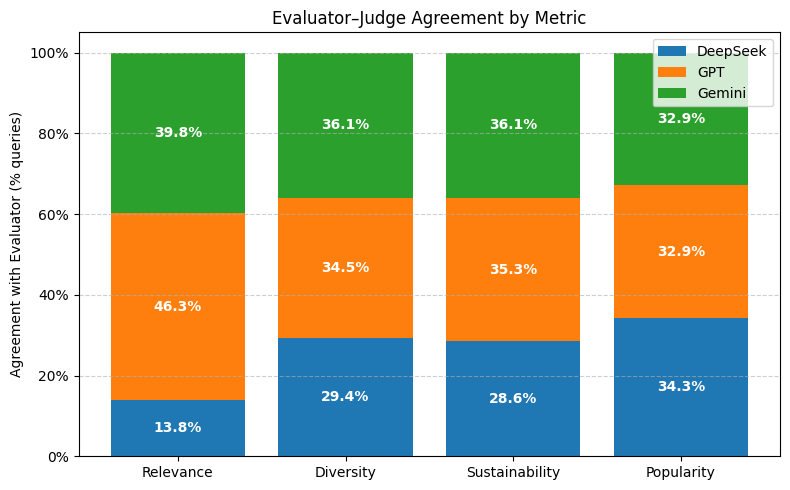

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Raw data
metrics = ["Relevance", "Diversity", "Sustainability", "Popularity"]
deepseek = np.array([0.17, 0.35, 0.34, 0.48])
gpt = np.array([0.57, 0.41, 0.42, 0.46])
gemini = np.array([0.49, 0.43, 0.43, 0.46])

# Normalize to get percentage shares per metric
totals = deepseek + gpt + gemini
deepseek_share = deepseek / totals
gpt_share = gpt / totals
gemini_share = gemini / totals

# Plot
x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(8, 5))

# Bars
bars_ds = ax.bar(x, deepseek_share, label='DeepSeek')
bars_gpt = ax.bar(x, gpt_share, bottom=deepseek_share, label='GPT')
bars_gemini = ax.bar(x, gemini_share, bottom=deepseek_share + gpt_share, label='Gemini')

# Add percentage labels inside each segment
for i in range(len(metrics)):
    # DeepSeek label
    ax.text(x[i], deepseek_share[i] / 2, f"{deepseek_share[i]*100:.1f}%", ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    # GPT label
    ax.text(x[i], deepseek_share[i] + gpt_share[i] / 2, f"{gpt_share[i]*100:.1f}%", ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    # Gemini label
    ax.text(x[i], deepseek_share[i] + gpt_share[i] + gemini_share[i] / 2, f"{gemini_share[i]*100:.1f}%", ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Formatting
ax.set_ylabel('Agreement with Evaluator (% queries)')
ax.set_title('Evaluator–Judge Agreement by Metric')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Format as percentages on Y axis
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])

ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [147]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
def plot_bar_chart(model_name):
    metrics = ['Relevance', 'Diversity', 'Sustainability', 'Popularity']

    # # Agreement percentages
    # deepseek = [0.17, 0.35, 0.34, 0.48]
    # gpt = [0.57, 0.41, 0.42, 0.46]
    # gemini = [0.49, 0.43, 0.43, 0.46]

    # # Convert to percentages (optional, for readability)
    # deepseek = [x * 100 for x in deepseek]
    # gpt = [x * 100 for x in gpt]
    # gemini = [x * 100 for x in gemini]

    # Bar positions
    x = np.arange(len(metrics))
    width = 0.25  # width of each bar

    # Create figure
    plt.figure(figsize=(9, 6))

    # Plot bars
    plt.bar(x - width, agreement_scores[model_name], width, label=f'{model_name.capitalize()}')
    # plt.bar(x, agreement_scores['gpt'], width, label='GPT')
    # plt.bar(x + width, agreement_scores['gemini'], width, label='Gemini')
    plt.bar(x, agreement_scores[f'calibrated_{model_name}'], width, label=f'Calibrated {model_name.capitalize()}')

    # Labels and title
    plt.ylabel('Agreement with Human Evaluators (% queries)')
    # plt.title('Evaluator–Judge Agreement Across Models and Metrics')
    plt.xticks(x, metrics)
    plt.ylim(0, 70)
    plt.legend()

    # Add grid and improve layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Show the chart
    plt.savefig(f"../../../plots/rq2a_judge_eval_agreement{model_name}.pdf", bbox_inches="tight")
    plt.show()


In [148]:
agreement_df.head()

,deepseek,gpt,gemini,calibrated_deepseek,calibrated_gpt,calibrated_gemini
0,17.0,57.0,49.0,21.0,57.0,49.0
1,35.0,41.0,43.0,24.0,41.0,42.0
2,34.0,42.0,43.0,34.0,42.0,41.0
3,48.0,46.0,46.0,47.0,46.0,47.0


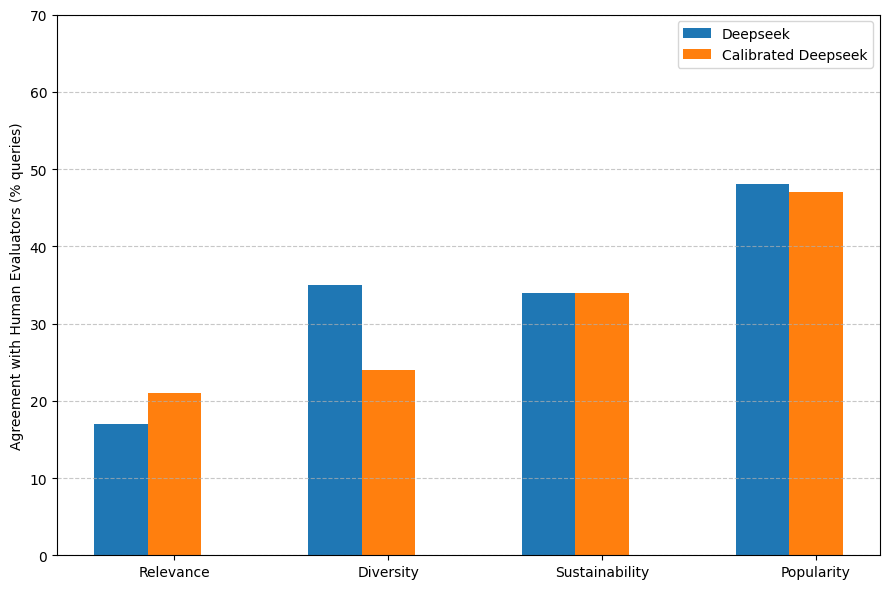

In [149]:
plot_bar_chart("deepseek")

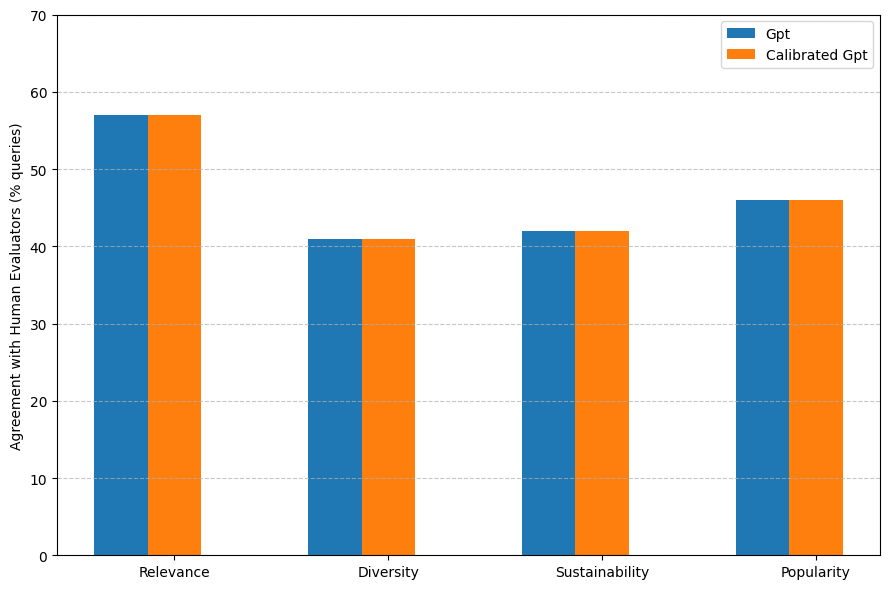

In [150]:
plot_bar_chart("gpt")

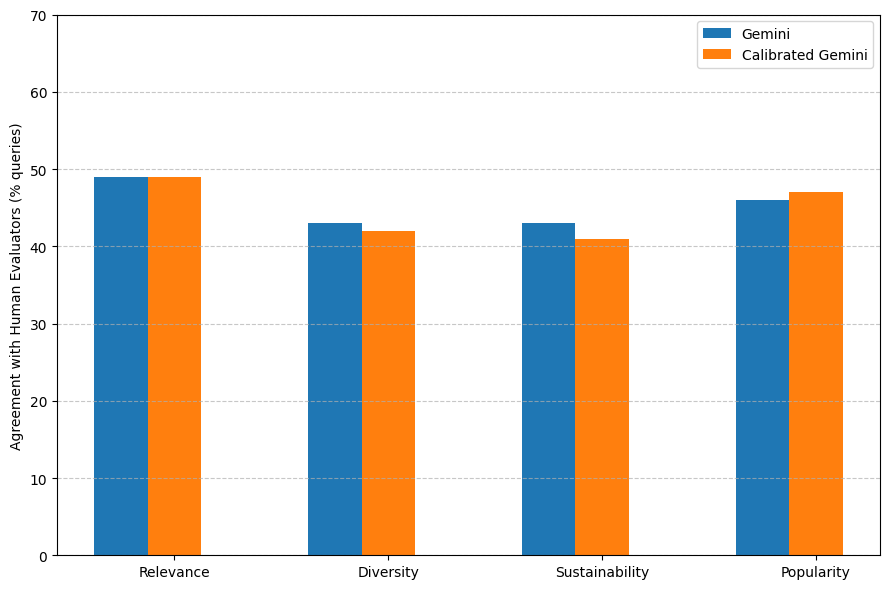

In [151]:
plot_bar_chart("gemini")